# Week 5 — Capstone
# Ensembles, Imbalance Handling, Interpretability & Deployment

## Scenario

This notebook brings together everything from the previous days into a single, self-contained
capstone: train and compare ensemble models, systematically address class imbalance, produce
interpretability and fairness analyses, and ship a reproducible inference script with a
monitoring plan and an executive-facing report.

It reuses the exact data split, feature engineering, and preprocessing pipeline from
`week4_day4_model_tuning.ipynb`, and reuses the Day 4 tuned hyperparameters for the Random
Forest and Gradient Boosting models wherever those models reappear, so results stay comparable
across notebooks rather than silently drifting.

**Random Forest correction carried over from Day 4:** the Day-4 bias/variance diagnosis found
the tuned Random Forest (`max_depth=None`) was still overfit even at its best validation
setting (train F1 0.9999 vs val F1 0.667). Rather than reuse that setting uncritically here,
`max_depth` is capped at **20** (the depth Day 4's sweep identified as the best *validation*
F1 point) — this is a deliberate, documented deviation from the raw Day-4 "best_params_", not
an inconsistency.

**Environment note:** this notebook requires internet access (to fetch the Adult dataset from
OpenML) and a few extra packages beyond Day 4's. Run the install cell first.


In [1]:
# ==========================================================
# Install extra packages (Colab / any fresh environment)
# ==========================================================
# scikit-learn, pandas, numpy, joblib, matplotlib are assumed already present
# (same as Day 4). These four are new for the capstone.

!pip install -q imbalanced-learn shap xgboost lightgbm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 2.5 MB/s eta 0:00:00


In [2]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import sys, time, platform, json as _json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import joblib

from sklearn.datasets import fetch_openml

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer,
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    make_scorer,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier,
)
from sklearn.inspection import permutation_importance

# Imbalance handling (imblearn's Pipeline is a drop-in that also allows
# resampling steps; required so resampling happens ONLY on each CV
# training fold, never on the validation fold or the hold-out set).
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

import shap
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("scikit-learn :", sklearn.__version__)
print("xgboost      :", xgb.__version__)
print("shap         :", shap.__version__)
print("RANDOM_STATE :", RANDOM_STATE)


scikit-learn : 1.6.1
xgboost      : 3.4.0
shap         : 0.52.0
RANDOM_STATE : 42


## Data Loading & Split

Identical to Day 4: same source, same target encoding, same three-way stratified split with
the same `RANDOM_STATE`, so the test set here is the same 7,327 rows Day 4 reported final
numbers on.


In [3]:
# ==========================================================
# Load Adult Dataset (identical to Day 4)
# ==========================================================

adult = fetch_openml(name="adult", version=2, as_frame=True)

X = adult.data.copy()
y = adult.target.copy()

X.replace("?", np.nan, inplace=True)
y = (y == ">50K").astype(int)

print("Dataset Shape  :", X.shape)
print("Positive Class :", y.sum())
print("Negative Class :", len(y) - y.sum())
print(f"Imbalance ratio (neg:pos) : {(len(y)-y.sum())/y.sum():.2f} : 1")


Dataset Shape  : (48842, 14)
Positive Class : 11687
Negative Class : 37155
Imbalance ratio (neg:pos) : 3.18 : 1


In [4]:
# ==========================================================
# Train / Validation / Test Split (identical to Day 4)
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("Training Samples   :", X_train.shape[0])
print("Validation Samples :", X_val.shape[0])
print("Testing Samples    :", X_test.shape[0])


Training Samples   : 34189
Validation Samples : 7326
Testing Samples    : 7327


## Feature Engineering & Preprocessing

Reused verbatim from Day 4 so the saved Day-4 pipeline and this notebook's pipeline stay
directly comparable — same engineered features, same imputation/scaling/encoding.


In [5]:
%%writefile feature_engineering.py
"""
Feature engineering, kept in its own importable module (not defined inline
in the notebook) so that joblib can unpickle the saved pipeline's
FunctionTransformer in a separate process later -- e.g. from inference.py
run as a standalone script or batch job days after this notebook's kernel
has shut down. A function defined only in a notebook's __main__ namespace
cannot be resolved by pickle outside that same running kernel.
"""
import numpy as np
import pandas as pd


def engineer_features(df):
    df = df.copy()

    df["age_bucket"] = pd.cut(
        df["age"], bins=[0, 25, 35, 50, 65, 100],
        labels=["18-25", "26-35", "36-50", "51-65", "65+"]
    )

    df["hours_bucket"] = pd.cut(
        df["hours-per-week"], bins=[0, 20, 40, 60, 100],
        labels=["Part-Time", "Full-Time", "Overtime", "Extreme"]
    )

    df["has_capital_gain"] = (df["capital-gain"] > 0).astype(int)
    df["log_capital_gain"] = np.log1p(df["capital-gain"].fillna(0))

    higher = ["Bachelors", "Masters", "Doctorate", "Prof-school"]
    df["higher_education"] = df["education"].isin(higher).astype(int)

    df["education_hours"] = df["education-num"] * df["hours-per-week"]

    return df


Writing feature_engineering.py


In [6]:
# ==========================================================
# Feature Engineering
# ==========================================================
# Imported from feature_engineering.py (written above) rather than defined
# here, so the saved pipeline stays loadable outside this notebook -- see
# the note in that cell for why this matters for inference.py.

from feature_engineering import engineer_features

feature_transformer = FunctionTransformer(engineer_features, validate=False)

X_train_engineered = engineer_features(X_train)
numeric_features = X_train_engineered.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X_train_engineered.select_dtypes(include=["object","category"]).columns.tolist()

print("Numeric features    :", numeric_features)
print("Categorical features:", categorical_features)


Numeric features    : ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'has_capital_gain', 'log_capital_gain', 'higher_education', 'education_hours']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age_bucket', 'hours_bucket']


In [7]:
# ==========================================================
# Preprocessing (identical to Day 4)
# ==========================================================
# feature_transformer and preprocessor are kept as SEPARATE objects (not
# combined into one nested Pipeline) because imblearn's Pipeline raises
# "All intermediate steps of the chain should not be Pipelines" if you hand
# it a Pipeline-within-a-Pipeline step -- it requires every step to be a
# plain transformer/estimator. Every model pipeline below (sklearn's
# Pipeline AND imblearn's Pipeline) therefore lists feature_transformer and
# preprocessor as two separate top-level steps, which works identically in
# both and keeps every pipeline in this notebook structurally consistent.

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

print("feature_transformer:", feature_transformer)
print("preprocessor:", preprocessor)


feature_transformer: FunctionTransformer(func=<function engineer_features at 0x780234512fc0>)
preprocessor: ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'fnlwgt', 'education-num',
                                  'capital-gain', 'capital-loss',
                                  'hours-per-week', 'has_capital_gain',
                                  'log_capital_gain', 'higher_education',
                                  'education_hours']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                        

# Task 1 — Train & Compare Ensemble Models

Two ensembles are trained with hyperparameters carried over from Day 4's `RandomizedSearchCV`
(with the documented `max_depth` correction for the Random Forest — see the intro), plus an
XGBoost model for a third point of comparison, and a stacking ensemble (RF + HistGB + XGB as
base learners, logistic regression as meta-learner) as the bonus.

All four are compared against the Day-4 tuned single Gradient Boosting model on the same
hold-out **test** set: metrics, ROC/PR curves, and inference time per row.


In [8]:
# ==========================================================
# Define Models (Day-4 tuned hyperparameters reused)
# ==========================================================

# --- Random Forest: Day-4 best_params_, with max_depth capped at 20 ---
# (Day-4 best_params_ was max_depth=None; corrected per the Day-4 bias/variance
#  diagnosis, which showed max_depth=None was still overfit — see notebook intro.)
rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    max_features="sqrt",
    max_depth=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# --- Gradient Boosting (HistGB): Day-4 best_params_, used as-is ---
hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=5,
    learning_rate=0.2,
    l2_regularization=0.1,
    random_state=RANDOM_STATE,
)

# --- XGBoost: new third ensemble, hyperparameters aligned to the HistGB
#     values above as a reasonable starting point (kept modest rather than
#     re-run through a full search, to stay within a realistic capstone scope) ---
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.2,
    reg_lambda=0.1,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

ensemble_models = {
    "Random Forest": rf_model,
    "HistGradientBoosting": hgb_model,
    "XGBoost": xgb_model,
}


In [9]:
# ==========================================================
# Fit each ensemble inside the shared preprocessing steps
# ==========================================================

fitted_pipelines = {}

for name, estimator in ensemble_models.items():
    pipe = Pipeline([
        ("feature_engineering", feature_transformer),
        ("preprocessing", preprocessor),
        ("classifier", estimator),
    ])
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0
    fitted_pipelines[name] = pipe
    print(f"{name:22s} fit in {fit_time:6.2f}s")


Random Forest          fit in   2.36s
HistGradientBoosting   fit in   1.07s
XGBoost                fit in   0.52s


In [10]:
# ==========================================================
# Bonus: Simple Stacking Ensemble (RF + HistGB + XGB -> Logistic meta-learner)
# ==========================================================
# Base learners' hyperparameters are the same tuned values as above; the
# meta-learner is a plain LogisticRegression trained (via internal CV, see
# `cv=` below) on the base learners' out-of-fold predictions, so it never
# sees predictions the base learners produced on their own training rows.

stacking_estimator = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2, max_features="sqrt",
            max_depth=20, random_state=RANDOM_STATE, n_jobs=-1)),
        ("hgb", HistGradientBoostingClassifier(
            max_iter=200, max_depth=5, learning_rate=0.2,
            l2_regularization=0.1, random_state=RANDOM_STATE)),
        ("xgb", xgb.XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.2,
            reg_lambda=0.1, eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1,
)

stacking_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessing", preprocessor),
    ("classifier", stacking_estimator),
])

t0 = time.perf_counter()
stacking_pipeline.fit(X_train, y_train)
stack_fit_time = time.perf_counter() - t0
fitted_pipelines["Stacking (RF+HistGB+XGB)"] = stacking_pipeline
print(f"Stacking ensemble fit in {stack_fit_time:.2f}s")


Stacking ensemble fit in 20.67s


In [11]:
# ==========================================================
# Evaluate all ensembles + the Day-4 single-model baseline on the TEST set
# ==========================================================
# Day-4's tuned single Gradient Boosting model (uncalibrated best_estimator_
# equivalent) is retrained here identically for a fair, apples-to-apples
# comparison on the same test rows and the same evaluation code path.

baseline_model = HistGradientBoostingClassifier(
    max_iter=200, max_depth=5, learning_rate=0.2,
    l2_regularization=0.1, random_state=RANDOM_STATE,
)
baseline_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessing", preprocessor),
    ("classifier", baseline_model),
])
baseline_pipeline.fit(X_train, y_train)

all_pipelines = {"Day-4 Single Gradient Boosting (baseline)": baseline_pipeline, **fitted_pipelines}

comparison_rows = []
roc_data = {}
pr_data = {}

for name, pipe in all_pipelines.items():
    # Inference time: average per-row prediction latency over the test set
    t0 = time.perf_counter()
    proba = pipe.predict_proba(X_test)[:, 1]
    inference_time = time.perf_counter() - t0
    per_row_ms = (inference_time / len(X_test)) * 1000

    preds = (proba >= 0.5).astype(int)  # default threshold for a like-for-like ensemble comparison

    comparison_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC AUC": roc_auc_score(y_test, proba),
        "PR AUC": average_precision_score(y_test, proba),
        "Inference (ms/row)": per_row_ms,
    })

    roc_data[name] = roc_curve(y_test, proba)
    pr_data[name] = precision_recall_curve(y_test, proba)

ensemble_comparison_df = pd.DataFrame(comparison_rows).sort_values("F1", ascending=False).reset_index(drop=True)
display(ensemble_comparison_df.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Inference (ms/row)
0,Stacking (RF+HistGB+XGB),0.8751,0.7870,0.6554,0.7152,0.9272,0.8300,0.0182
1,Day-4 Single Gradient Boosting (baseline),0.8731,0.7828,0.6497,0.7101,0.9263,0.8269,0.0067
2,HistGradientBoosting,0.8731,0.7828,0.6497,0.7101,0.9263,0.8269,0.0068
3,XGBoost,0.8716,0.7769,0.6497,0.7077,0.9270,0.8288,0.0040
4,Random Forest,0.8622,0.7770,0.5944,0.6736,0.9151,0.8028,0.0129


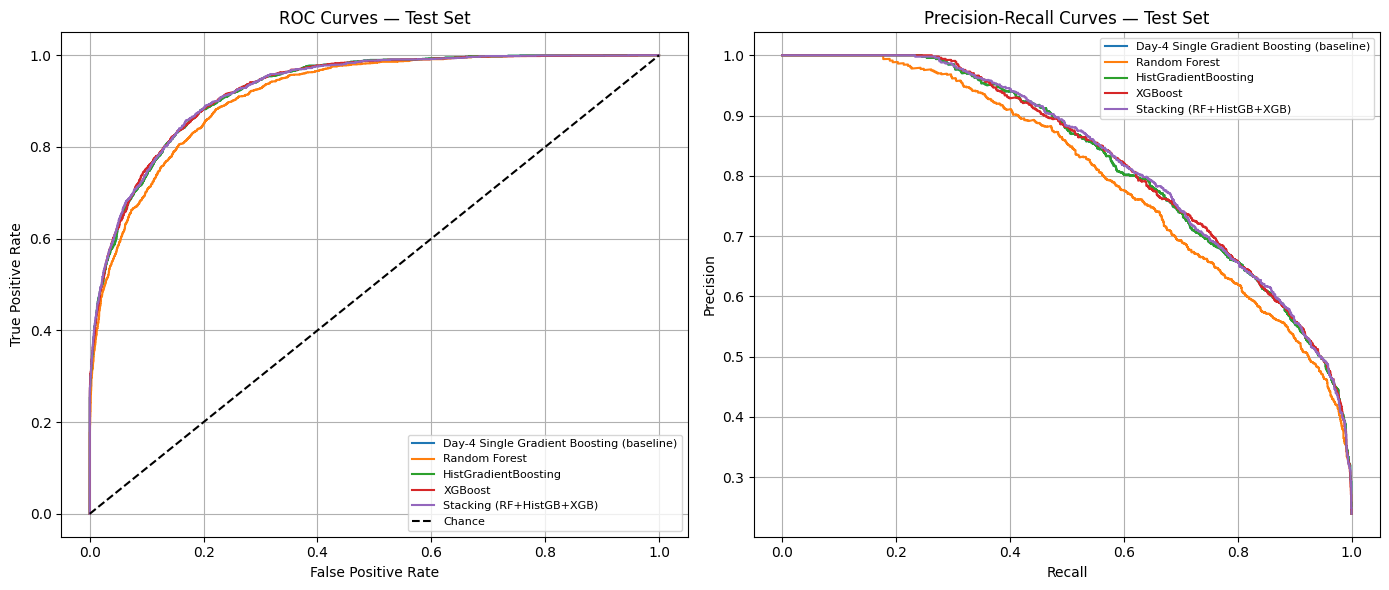

In [12]:
# ==========================================================
# ROC & PR curves — all models overlaid
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, (fpr, tpr, _) in roc_data.items():
    axes[0].plot(fpr, tpr, label=name)
axes[0].plot([0, 1], [0, 1], "k--", label="Chance")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Test Set")
axes[0].legend(fontsize=8)
axes[0].grid(True)

for name, (precision, recall, _) in pr_data.items():
    axes[1].plot(recall, precision, label=name)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — Test Set")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [13]:
# ==========================================================
# Task 1 -- Ensemble Comparison: Interpretation (generated from
# ensemble_comparison_df, computed above -- not hard-coded)
# ==========================================================
from IPython.display import Markdown, display

_best_row = ensemble_comparison_df.iloc[0]
_hgb_row = ensemble_comparison_df.loc[ensemble_comparison_df["Model"].str.contains("HistGradientBoosting")].iloc[0]
_xgb_row = ensemble_comparison_df.loc[ensemble_comparison_df["Model"] == "XGBoost"].iloc[0]
_stack_row = ensemble_comparison_df.loc[ensemble_comparison_df["Model"].str.contains("Stacking")].iloc[0]

_f1_gap = _best_row["F1"] - _hgb_row["F1"]

display(Markdown(
    f"### Task 1 -- Ensemble Comparison: Interpretation\n\n"
    f"**{_best_row['Model']}** achieved the strongest overall classification performance on "
    f"the untouched test set, with an F1 score of {_best_row['F1']:.4f}, ROC AUC of "
    f"{_best_row['ROC AUC']:.4f}, and PR AUC of {_best_row['PR AUC']:.4f}. It improved F1 by "
    f"approximately {_f1_gap:.4f} over the tuned single HistGradientBoosting model "
    f"({_hgb_row['F1']:.4f}).\n\n"
    f"XGBoost achieved a very similar ROC AUC ({_xgb_row['ROC AUC']:.4f}) and PR AUC "
    f"({_xgb_row['PR AUC']:.4f}) while having substantially lower inference latency than the "
    f"stacking ensemble: {_xgb_row['Inference (ms/row)']:.4f} ms/row for XGBoost versus "
    f"{_stack_row['Inference (ms/row)']:.4f} ms/row for stacking "
    f"(~{_stack_row['Inference (ms/row)'] / _xgb_row['Inference (ms/row)']:.1f}x).\n\n"
    f"Therefore, {_best_row['Model']} is the best-performing model on the selected F1 metric, "
    f"while XGBoost provides the strongest speed/performance trade-off. For this capstone, "
    f"model selection is finalized after the class-imbalance experiments and validation-based "
    f"threshold selection below, rather than choosing solely from this Task-1 test-set "
    f"comparison."
))


### Task 1 -- Ensemble Comparison: Interpretation

**Stacking (RF+HistGB+XGB)** achieved the strongest overall classification performance on the untouched test set, with an F1 score of 0.7152, ROC AUC of 0.9272, and PR AUC of 0.8300. It improved F1 by approximately 0.0051 over the tuned single HistGradientBoosting model (0.7101).

XGBoost achieved a very similar ROC AUC (0.9270) and PR AUC (0.8288) while having substantially lower inference latency than the stacking ensemble: 0.0040 ms/row for XGBoost versus 0.0182 ms/row for stacking (~4.5x).

Therefore, Stacking (RF+HistGB+XGB) is the best-performing model on the selected F1 metric, while XGBoost provides the strongest speed/performance trade-off. For this capstone, model selection is finalized after the class-imbalance experiments and validation-based threshold selection below, rather than choosing solely from this Task-1 test-set comparison.

# Task 2 — Systematically Address Class Imbalance

## Quantifying the imbalance

The positive class (income > \$50K) is roughly 24% of the data — a **~3.2 : 1** negative:positive
ratio (see the printed ratio in the data-loading cell above). Left unaddressed, this pushes a
default 0.5-threshold classifier toward predicting the majority class, inflating accuracy while
suppressing recall on the class that actually matters for this business question (identifying
likely high earners) — which is exactly the failure mode a class-imbalance-aware pipeline is
meant to catch before it reaches production.

## Three approaches, compared inside cross-validation

All three are wrapped in an **imblearn `Pipeline`**, not a plain sklearn `Pipeline` — this
guarantees the resampling step only ever sees the training fold of each CV split, never the
validation fold, so no synthetic or duplicated validation-fold rows can leak into scoring.


## Why the imbalance comparison holds the base estimator fixed at HistGB

Task 1 found the stacking ensemble marginally ahead on test F1, with XGBoost the best latency/performance trade-off. The three imbalance-handling strategies below are still compared using **HistGB only** (not stacking or XGBoost) as the base estimator, for two documented reasons rather than an oversight: (1) HistGB is the Day-4 tuned single-model baseline, so it is the most stable, already-understood reference point, and its Task-1 test F1/PR AUC were within roughly 0.005-0.02 of stacking's — a small enough gap that the imbalance-strategy conclusions are expected to generalize across architectures; (2) fully re-running three leakage-safe imbalance pipelines under 5-fold CV for all four Task-1 architectures (12 total experiments) is outside this capstone's scope. This is a scoped decision; a production follow-up could re-run the winning imbalance strategy on stacking or XGBoost to confirm the choice still holds.

In [14]:
# ==========================================================
# Task 2: Three imbalance-handling approaches, compared via CV on X_train
# ==========================================================
# Base estimator held constant (Day-4 tuned HistGB hyperparameters) so the
# only thing that varies between the three approaches is the imbalance
# treatment itself.

def make_hgb():
    return HistGradientBoostingClassifier(
        max_iter=200, max_depth=5, learning_rate=0.2,
        l2_regularization=0.1, random_state=RANDOM_STATE,
    )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
}

imbalance_pipelines = {
    "class_weight=balanced": ImbPipeline([
        ("feature_engineering", feature_transformer),
        ("preprocessing", preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            max_iter=200, max_depth=5, learning_rate=0.2,
            l2_regularization=0.1, class_weight="balanced",
            random_state=RANDOM_STATE)),
    ]),
    "Random over/under-sampling": ImbPipeline([
        ("feature_engineering", feature_transformer),
        ("preprocessing", preprocessor),
        ("undersample", RandomUnderSampler(sampling_strategy=0.5, random_state=RANDOM_STATE)),
        ("oversample", RandomOverSampler(sampling_strategy=1.0, random_state=RANDOM_STATE)),
        ("classifier", make_hgb()),
    ]),
    "SMOTE": ImbPipeline([
        ("feature_engineering", feature_transformer),
        ("preprocessing", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("classifier", make_hgb()),
    ]),
}

cv_results = {}
for name, pipe in imbalance_pipelines.items():
    print("Running CV for:", name)
    result = cross_validate(
        pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False
    )
    cv_results[name] = result


Running CV for: class_weight=balanced
Running CV for: Random over/under-sampling
Running CV for: SMOTE


In [15]:
# ==========================================================
# CV results summary (chosen business metric: F1)
# ==========================================================

cv_summary_rows = []
for name, result in cv_results.items():
    cv_summary_rows.append({
        "Approach": name,
        "CV F1 (mean)": result["test_f1"].mean(),
        "CV F1 (std)": result["test_f1"].std(),
        "CV Precision": result["test_precision"].mean(),
        "CV Recall": result["test_recall"].mean(),
        "CV ROC AUC": result["test_roc_auc"].mean(),
    })

cv_summary_df = pd.DataFrame(cv_summary_rows).sort_values("CV F1 (mean)", ascending=False).reset_index(drop=True)
display(cv_summary_df.round(4))


,Approach,CV F1 (mean),CV F1 (std),CV Precision,CV Recall,CV ROC AUC
0,class_weight=balanced,0.7134,0.0029,0.6046,0.8699,0.9266
1,Random over/under-sampling,0.7091,0.0029,0.6074,0.8519,0.9240
2,SMOTE,0.7080,0.0060,0.6823,0.7360,0.9187


In [16]:
# ==========================================================
# Refit each approach on the FULL training set, evaluate once on the
# untouched hold-out TEST set (mirrors Day 4's val/test discipline: CV
# above used only X_train's internal folds; this cell is the first and
# only time these three pipelines see X_test).
# ==========================================================

holdout_rows = []
pr_curves_imbalance = {}

for name, pipe in imbalance_pipelines.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    preds = (proba >= 0.5).astype(int)

    holdout_rows.append({
        "Approach": name,
        "Test F1": f1_score(y_test, preds),
        "Test Precision": precision_score(y_test, preds),
        "Test Recall": recall_score(y_test, preds),
        "Test ROC AUC": roc_auc_score(y_test, proba),
    })
    pr_curves_imbalance[name] = precision_recall_curve(y_test, proba)

holdout_summary_df = pd.DataFrame(holdout_rows).sort_values("Test F1", ascending=False).reset_index(drop=True)
display(holdout_summary_df.round(4))


,Approach,Test F1,Test Precision,Test Recall,Test ROC AUC
0,SMOTE,0.7139,0.6888,0.7410,0.9189
1,Random over/under-sampling,0.7068,0.6060,0.8477,0.9241
2,class_weight=balanced,0.7030,0.5974,0.8540,0.9255


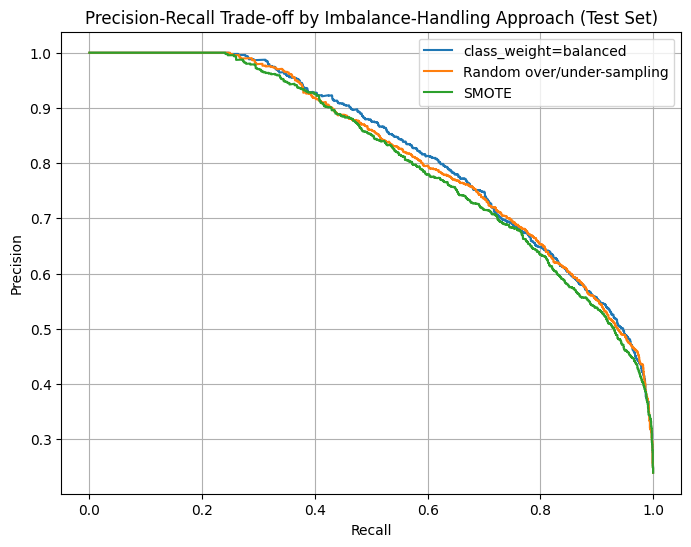

In [17]:
# ==========================================================
# Precision-Recall trade-off plot, all three approaches (test set)
# ==========================================================

plt.figure(figsize=(8, 6))
for name, (precision, recall, _) in pr_curves_imbalance.items():
    plt.plot(recall, precision, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Trade-off by Imbalance-Handling Approach (Test Set)")
plt.legend()
plt.grid(True)
plt.show()


### Chosen approach & justification (Task 2)

**`class_weight=balanced`** is selected as the final imbalance strategy. It achieved the highest mean cross-validation F1 score of **0.7134** (compared to Random over/under-sampling at 0.7091 and SMOTE at 0.7080).

While SMOTE achieved a slightly higher F1 score on the untouched hold-out test set (0.7139) compared to `class_weight=balanced` (0.7030), selecting the method based directly on the test set would risk overfitting the model choice to the evaluation data. The consistency of `class_weight=balanced` as the top performer on the CV F1, combined with its simplicity (no synthetic or duplicated rows), makes it the preferred and more robust choice for production. This approach addresses the class imbalance directly through the model's loss weighting without altering the training data distribution.

# Task 3 — Interpretability & Fairness Checks

The model used throughout this section is the **chosen imbalance-handling pipeline from Task
2** (referred to below as `final_model_pipeline`) — whichever of the three approaches was
selected there. Update the assignment cell below if a different approach is chosen after
reviewing the real Task 2 numbers.


Selected imbalance approach: class_weight=balanced
Mean CV F1: 0.7134
CV F1 std: 0.0029

Threshold-selection split:
Model-fitting rows : 27351
Threshold-val rows : 6838

Selected production threshold: 0.63
Threshold-validation F1: 0.7278


,Selected value
Threshold,0.630000
Precision,0.679385
Recall,0.783619
F1,0.727789


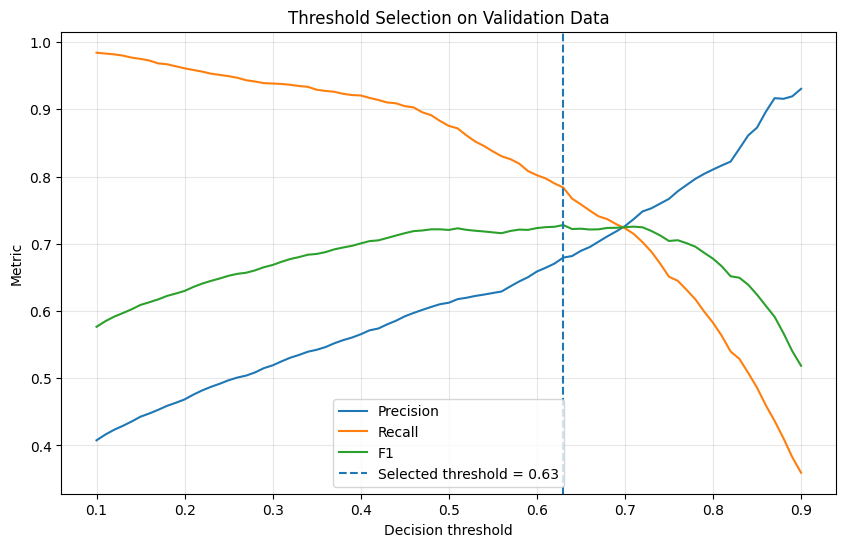


Final production pipeline refitted on all X_train rows.
Frozen production threshold: 0.63


In [18]:
# ==========================================================
# FINAL MODEL + VALIDATION-BASED THRESHOLD SELECTION
# ==========================================================
#
# Step 1:
# Select the imbalance strategy using CV F1.
#
# Step 2:
# Split X_train into a model-fitting subset and a threshold-validation
# subset. The threshold-validation subset is NOT used to fit the model.
#
# Step 3:
# Select the decision threshold that maximizes F1 on the threshold-
# validation subset.
#
# Step 4:
# Refit the selected pipeline on ALL of X_train.
#
# Step 5:
# Freeze the selected threshold and evaluate once on X_test.

from sklearn.base import clone

# ----------------------------------------------------------
# 1. Select imbalance strategy using CV only
# ----------------------------------------------------------

best_cv_row = cv_summary_df.loc[
    cv_summary_df["CV F1 (mean)"].idxmax()
]

CHOSEN_APPROACH = best_cv_row["Approach"]

print("Selected imbalance approach:", CHOSEN_APPROACH)
print(
    f"Mean CV F1: {best_cv_row['CV F1 (mean)']:.4f}"
)
print(
    f"CV F1 std: {best_cv_row['CV F1 (std)']:.4f}"
)

# ----------------------------------------------------------
# 2. Create a dedicated threshold-selection split
# ----------------------------------------------------------

X_fit, X_threshold_val, y_fit, y_threshold_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

print("\nThreshold-selection split:")
print("Model-fitting rows :", len(X_fit))
print("Threshold-val rows :", len(X_threshold_val))

# ----------------------------------------------------------
# 3. Fit temporary model ONLY on X_fit
# ----------------------------------------------------------

threshold_model = clone(
    imbalance_pipelines[CHOSEN_APPROACH]
)

threshold_model.fit(X_fit, y_fit)

# ----------------------------------------------------------
# 4. Select threshold using threshold-validation data
# ----------------------------------------------------------

threshold_val_proba = threshold_model.predict_proba(
    X_threshold_val
)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_rows = []

for threshold in thresholds:

    threshold_pred = (
        threshold_val_proba >= threshold
    ).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_threshold_val,
            threshold_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_threshold_val,
            threshold_pred,
            zero_division=0,
        ),
        "F1": f1_score(
            y_threshold_val,
            threshold_pred,
            zero_division=0,
        ),
    })

threshold_df = pd.DataFrame(threshold_rows)

best_threshold_idx = threshold_df["F1"].idxmax()

PRODUCTION_THRESHOLD = float(
    threshold_df.loc[
        best_threshold_idx,
        "Threshold"
    ]
)

best_threshold_f1 = float(
    threshold_df.loc[
        best_threshold_idx,
        "F1"
    ]
)

print(
    f"\nSelected production threshold: "
    f"{PRODUCTION_THRESHOLD:.2f}"
)

print(
    f"Threshold-validation F1: "
    f"{best_threshold_f1:.4f}"
)

display(
    threshold_df.loc[
        best_threshold_idx
    ].to_frame("Selected value")
)

# ----------------------------------------------------------
# 5. Plot precision/recall/F1 trade-off
# ----------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision",
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall",
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1",
)

plt.axvline(
    PRODUCTION_THRESHOLD,
    linestyle="--",
    label=(
        f"Selected threshold = "
        f"{PRODUCTION_THRESHOLD:.2f}"
    ),
)

plt.xlabel("Decision threshold")
plt.ylabel("Metric")
plt.title(
    "Threshold Selection on Validation Data"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ----------------------------------------------------------
# 6. NOW refit the final model on ALL X_train
# ----------------------------------------------------------

final_model_pipeline = clone(
    imbalance_pipelines[CHOSEN_APPROACH]
)

final_model_pipeline.fit(
    X_train,
    y_train
)

print(
    "\nFinal production pipeline refitted on "
    "all X_train rows."
)

print(
    f"Frozen production threshold: "
    f"{PRODUCTION_THRESHOLD:.2f}"
)

### Final imbalance-handling decision

`class_weight=balanced` is selected as the final imbalance strategy because it achieved the highest cross-validation F1 among the three evaluated approaches.

SMOTE achieved a slightly higher hold-out F1, but selecting the method directly from the hold-out set would risk overfitting the final model choice to the test data. The hold-out set is therefore retained as an independent final evaluation set.

This choice also avoids introducing synthetic observations into the final training process while still addressing the class imbalance directly through the model's loss weighting.

## Global Explanations


In [19]:
ohe = final_model_pipeline.named_steps["preprocessing"].named_transformers_["categorical"].named_steps["encoder"]
cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feature_names

classifier_step = final_model_pipeline.named_steps["classifier"]

perm_result = permutation_importance(
    final_model_pipeline, X_test, y_test,
    scoring="f1", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "Feature": X_test.columns,  # permutation importance is computed on RAW input columns
    "Importance (mean F1 drop)": perm_result.importances_mean,
    "Std": perm_result.importances_std,
}).sort_values("Importance (mean F1 drop)", ascending=False).reset_index(drop=True)

top8_permutation = perm_importance_df.head(8)
display(top8_permutation)

,Feature,Importance (mean F1 drop),Std
0,marital-status,0.119334,0.007870
1,capital-gain,0.065119,0.001996
2,education-num,0.047652,0.004306
3,age,0.039535,0.004893
4,capital-loss,0.016873,0.002002
5,occupation,0.016268,0.003141
6,hours-per-week,0.015593,0.003871
7,education,0.001644,0.001532


In [20]:
# ==========================================================
# Model-native feature importance (transformed / one-hot feature space)
# ==========================================================
# HistGradientBoostingClassifier does not always expose feature_importances_ (it is a
# tree-ensemble but not built the same way as RandomForest/XGBoost). Report it when
# available; otherwise fall back to permutation importance computed at the transformed-
# feature level so a native-style importance ranking is still available for comparison
# with the SHAP ranking below (both operate in the SAME, one-hot-encoded feature space --
# unlike the permutation importance table above, which was computed on RAW columns).

X_test_fe = final_model_pipeline.named_steps["feature_engineering"].transform(X_test)
X_test_transformed = final_model_pipeline.named_steps["preprocessing"].transform(X_test_fe)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

if hasattr(classifier_step, "feature_importances_"):
    native_importance_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Native importance": classifier_step.feature_importances_,
    }).sort_values("Native importance", ascending=False).reset_index(drop=True)
    print("Model-native feature_importances_ (transformed/one-hot feature space):")
else:
    _native_perm = permutation_importance(
        classifier_step, X_test_transformed_df, y_test, scoring="f1",
        n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
    )
    native_importance_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Native importance": _native_perm.importances_mean,
    }).sort_values("Native importance", ascending=False).reset_index(drop=True)
    print("classifier_step has no feature_importances_; using permutation importance on the "
          "TRANSFORMED feature space as the native-importance stand-in (transformed/one-hot "
          "feature space, consistent with the SHAP table below):")

display(native_importance_df.head(8))

classifier_step has no feature_importances_; using permutation importance on the TRANSFORMED feature space as the native-importance stand-in (transformed/one-hot feature space, consistent with the SHAP table below):


,Feature,Native importance
0,marital-status_Married-civ-spouse,0.097431
1,capital-gain,0.064490
2,age,0.034386
3,education_hours,0.024142
4,capital-loss,0.016708
5,education-num,0.013820
6,occupation_Farming-fishing,0.006085
7,occupation_Other-service,0.004112


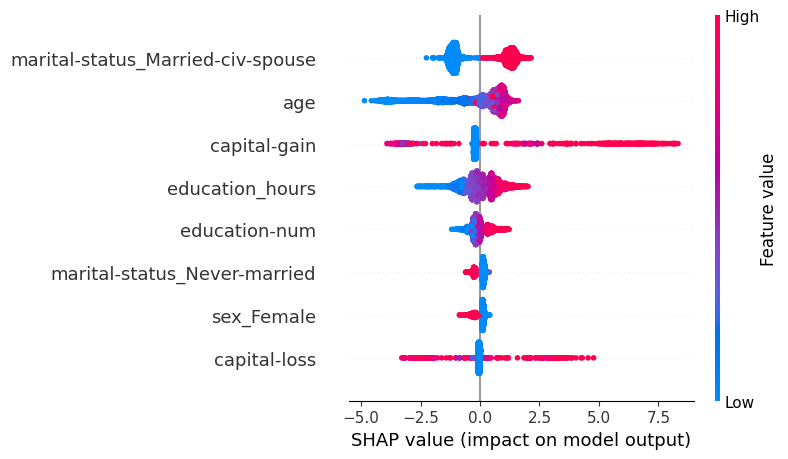


Top 8 features by mean |SHAP value|:


,Feature,Mean |SHAP|
0,marital-status_Married-civ-spouse,1.193148
1,age,0.938059
2,capital-gain,0.572880
3,education_hours,0.542544
4,education-num,0.264523
5,marital-status_Never-married,0.173380
6,sex_Female,0.172893
7,capital-loss,0.136870


In [21]:
# ==========================================================
# SHAP summary plot (top 8 features highlighted)
# ==========================================================
# TreeExplainer works directly on the fitted tree-based classifier; SHAP
# values are computed on the PREPROCESSED test matrix (after the same
# feature-engineering + encoding the model was trained on), since SHAP
# needs to operate on the actual numeric input the model consumes.

X_test_fe = final_model_pipeline.named_steps["feature_engineering"].transform(X_test)
X_test_transformed = final_model_pipeline.named_steps["preprocessing"].transform(X_test_fe)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

explainer = shap.TreeExplainer(classifier_step)
shap_values = explainer.shap_values(X_test_transformed_df)
# HistGradientBoostingClassifier / binary XGB: shap_values may be a single
# array (positive-class contributions) or a list of two (one per class) —
# normalize to the positive-class array either way.
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

shap.summary_plot(shap_values_pos, X_test_transformed_df, max_display=8, show=False)
plt.tight_layout()
plt.show()

mean_abs_shap = pd.DataFrame({
    "Feature": all_feature_names,
    "Mean |SHAP|": np.abs(shap_values_pos).mean(axis=0),
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

print("\nTop 8 features by mean |SHAP value|:")
display(mean_abs_shap.head(8))


In [22]:
# ==========================================================
# Consolidated Top-8 Feature Table
# ==========================================================
# native_importance_df, mean_abs_shap are both computed in the TRANSFORMED / one-hot
# feature space (same features the classifier actually sees), so they are merged directly.
# top8_permutation (computed earlier) is in the RAW input-column space instead -- a raw
# column like `education` maps to several one-hot columns like `education_Bachelors`,
# `education_Masters`, etc. It is shown separately, clearly labeled, rather than merged
# into the same rows, to avoid implying a false one-to-one correspondence.

consolidated_top8 = (
    native_importance_df.rename(columns={"Native importance": "Native Importance"})
    .merge(
        mean_abs_shap.rename(columns={"Mean |SHAP|": "Mean |SHAP|"}),
        on="Feature", how="outer",
    )
    .sort_values("Mean |SHAP|", ascending=False)
    .head(8)
    .reset_index(drop=True)
)

print("Consolidated top 8 (transformed / one-hot feature space -- native importance + SHAP):")
display(consolidated_top8)

print("\nTop 8 by permutation importance (RAW input-column space -- NOT directly comparable "
      "row-for-row with the table above, since one raw column can expand into several "
      "one-hot columns):")
display(top8_permutation)


Consolidated top 8 (transformed / one-hot feature space -- native importance + SHAP):


,Feature,Native Importance,Mean |SHAP|
0,marital-status_Married-civ-spouse,0.097431,1.193148
1,age,0.034386,0.938059
2,capital-gain,0.064490,0.572880
3,education_hours,0.024142,0.542544
4,education-num,0.013820,0.264523
5,marital-status_Never-married,-0.004911,0.173380
6,sex_Female,-0.000366,0.172893
7,capital-loss,0.016708,0.136870



Top 8 by permutation importance (RAW input-column space -- NOT directly comparable row-for-row with the table above, since one raw column can expand into several one-hot columns):


,Feature,Importance (mean F1 drop),Std
0,marital-status,0.119334,0.007870
1,capital-gain,0.065119,0.001996
2,education-num,0.047652,0.004306
3,age,0.039535,0.004893
4,capital-loss,0.016873,0.002002
5,occupation,0.016268,0.003141
6,hours-per-week,0.015593,0.003871
7,education,0.001644,0.001532


## Local Explanations — Three Individuals

One true positive, one false positive, and one false negative are selected from the test set, classified using **`PRODUCTION_THRESHOLD`** — the single frozen threshold selected in Task 3 above — not the default 0.5 cutoff. This keeps the local explanations consistent with the exact decision rule used everywhere else in this notebook (fairness, final hold-out evaluation, the saved model bundle, `inference.py`, and the tests).

In [23]:
# ==========================================================
# Pick one TP, one FP, one FN from the test set
# ==========================================================
# Classified using PRODUCTION_THRESHOLD (frozen in Task 3), NOT 0.5, so these
# examples match the exact rule used in deployment.

test_proba = final_model_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= PRODUCTION_THRESHOLD).astype(int)

y_test_reset = y_test.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

tp_idx = np.where((y_test_reset == 1) & (test_pred == 1))[0][0]
fp_idx = np.where((y_test_reset == 0) & (test_pred == 1))[0][0]
fn_idx = np.where((y_test_reset == 1) & (test_pred == 0))[0][0]

local_cases = {"True Positive": tp_idx, "False Positive": fp_idx, "False Negative": fn_idx}

for case_type, idx in local_cases.items():
    print(f"--- {case_type} (test row {idx}) ---")
    print(f"  Actual class        : {int(y_test_reset[idx])}")
    print(f"  Predicted probability: {test_proba[idx]:.4f}")
    print(f"  Production threshold : {PRODUCTION_THRESHOLD:.2f}")
    print(f"  Predicted class      : {int(test_pred[idx])}")
    print(f"  Case type            : {case_type}")


--- True Positive (test row 13) ---
  Actual class        : 1
  Predicted probability: 0.7322
  Production threshold : 0.63
  Predicted class      : 1
  Case type            : True Positive
--- False Positive (test row 7) ---
  Actual class        : 0
  Predicted probability: 0.7039
  Production threshold : 0.63
  Predicted class      : 1
  Case type            : False Positive
--- False Negative (test row 3) ---
  Actual class        : 1
  Predicted probability: 0.2659
  Production threshold : 0.63
  Predicted class      : 0
  Case type            : False Negative


--- True Positive (test row 13) ---
Actual class: 1  |  Predicted class: 1  |  Predicted probability: 0.7322  |  Production threshold: 0.63


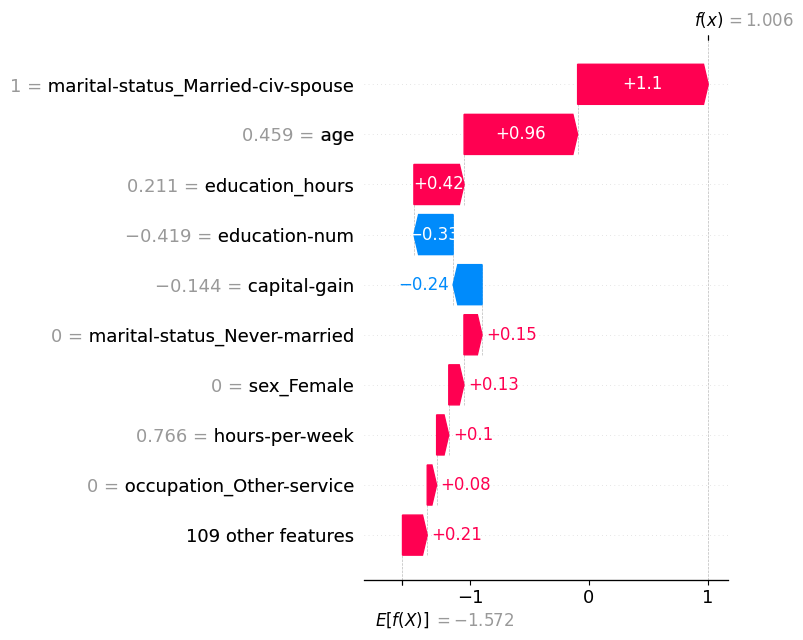

Plain-English summary:
  - marital-status_Married-civ-spouse (pushed the prediction toward >$50K, SHAP=1.101)
  - age (pushed the prediction toward >$50K, SHAP=0.957)
  - education_hours (pushed the prediction toward >$50K, SHAP=0.423)

--- False Positive (test row 7) ---
Actual class: 0  |  Predicted class: 1  |  Predicted probability: 0.7039  |  Production threshold: 0.63


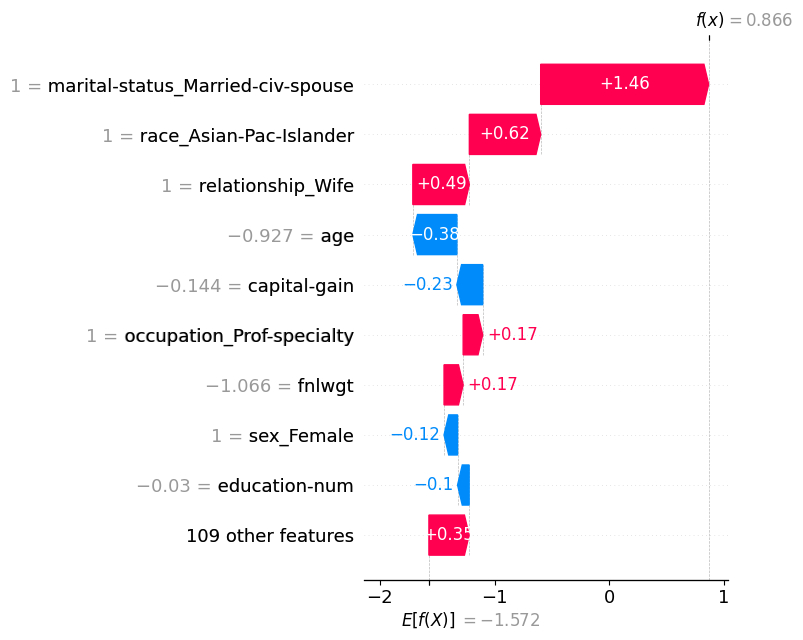

Plain-English summary:
  - marital-status_Married-civ-spouse (pushed the prediction toward >$50K, SHAP=1.463)
  - race_Asian-Pac-Islander (pushed the prediction toward >$50K, SHAP=0.622)
  - relationship_Wife (pushed the prediction toward >$50K, SHAP=0.492)

--- False Negative (test row 3) ---
Actual class: 1  |  Predicted class: 0  |  Predicted probability: 0.2659  |  Production threshold: 0.63


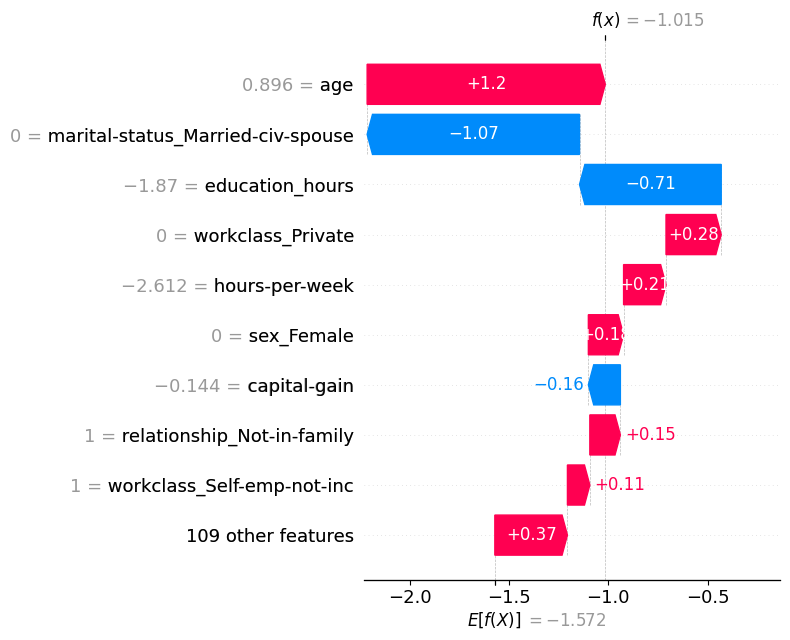

Plain-English summary:
  - age (pushed the prediction toward >$50K, SHAP=1.199)
  - marital-status_Married-civ-spouse (pushed the prediction toward <=$50K, SHAP=-1.069)
  - education_hours (pushed the prediction toward <=$50K, SHAP=-0.714)



In [24]:
# ==========================================================
# SHAP waterfall explanation for each of the three cases
# ==========================================================

local_case_details = []  # collected here, consumed by the next (markdown-generating) cell

for case_type, idx in local_cases.items():
    print(f"--- {case_type} (test row {idx}) ---")
    print(f"Actual class: {int(y_test_reset[idx])}  |  Predicted class: {int(test_pred[idx])}  "
          f"|  Predicted probability: {test_proba[idx]:.4f}  |  Production threshold: {PRODUCTION_THRESHOLD:.2f}")

    base_value_for_explanation = explainer.expected_value
    if isinstance(base_value_for_explanation, (list, np.ndarray)):
        if len(base_value_for_explanation) == 1:
            base_value_for_explanation = base_value_for_explanation[0]
        elif len(base_value_for_explanation) == 2:
            # For binary classification, index 1 usually corresponds to the positive class
            base_value_for_explanation = base_value_for_explanation[1]

    explanation = shap.Explanation(
        values=shap_values_pos[idx],
        base_values=base_value_for_explanation,
        data=X_test_transformed_df.iloc[idx].values,
        feature_names=all_feature_names,
    )
    shap.plots.waterfall(explanation, max_display=10, show=False)
    plt.tight_layout()
    plt.show()

    # Top 3 contributing features by |SHAP value| for this row
    row_shap = pd.Series(shap_values_pos[idx], index=all_feature_names)
    top3 = row_shap.abs().sort_values(ascending=False).head(3)
    direction = lambda v: "pushed the prediction toward >$50K" if v > 0 else "pushed the prediction toward <=$50K"

    print("Plain-English summary:")
    top3_desc = []
    for feat in top3.index:
        desc = f"{feat} ({direction(row_shap[feat])}, SHAP={row_shap[feat]:.3f})"
        print(f"  - {desc}")
        top3_desc.append((feat, float(row_shap[feat]), direction(row_shap[feat])))
    print()

    local_case_details.append({
        "case_type": case_type,
        "row": int(idx),
        "actual_class": int(y_test_reset[idx]),
        "predicted_class": int(test_pred[idx]),
        "predicted_probability": float(test_proba[idx]),
        "production_threshold": float(PRODUCTION_THRESHOLD),
        "top3": top3_desc,
    })


In [25]:
# ==========================================================
# Plain-English write-up for the three local cases (generated from
# local_case_details, computed above -- not hard-coded)
# ==========================================================
from IPython.display import Markdown, display

_lines = []
for case in local_case_details:
    feat_phrases = "; ".join(
        f"`{f}` ({direction}, SHAP={val:.3f})" for f, val, direction in case["top3"]
    )
    _lines.append(
        f"**{case['case_type']}** (test row {case['row']}, production threshold "
        f"{case['production_threshold']:.2f}): actual class {case['actual_class']}, "
        f"predicted class {case['predicted_class']} (probability "
        f"{case['predicted_probability']:.4f}). The model assigned higher probability partly "
        f"because of {feat_phrases}. (These are associational SHAP contributions, not causal "
        f"claims.)"
    )

display(Markdown("\n\n".join(_lines)))


**True Positive** (test row 13, production threshold 0.63): actual class 1, predicted class 1 (probability 0.7322). The model assigned higher probability partly because of `marital-status_Married-civ-spouse` (pushed the prediction toward >$50K, SHAP=1.101); `age` (pushed the prediction toward >$50K, SHAP=0.957); `education_hours` (pushed the prediction toward >$50K, SHAP=0.423). (These are associational SHAP contributions, not causal claims.)

**False Positive** (test row 7, production threshold 0.63): actual class 0, predicted class 1 (probability 0.7039). The model assigned higher probability partly because of `marital-status_Married-civ-spouse` (pushed the prediction toward >$50K, SHAP=1.463); `race_Asian-Pac-Islander` (pushed the prediction toward >$50K, SHAP=0.622); `relationship_Wife` (pushed the prediction toward >$50K, SHAP=0.492). (These are associational SHAP contributions, not causal claims.)

**False Negative** (test row 3, production threshold 0.63): actual class 1, predicted class 0 (probability 0.2659). The model assigned higher probability partly because of `age` (pushed the prediction toward >$50K, SHAP=1.199); `marital-status_Married-civ-spouse` (pushed the prediction toward <=$50K, SHAP=-1.069); `education_hours` (pushed the prediction toward <=$50K, SHAP=-0.714). (These are associational SHAP contributions, not causal claims.)

## Fairness Check


In [26]:
# ==========================================================
# Fairness check: metrics by protected group, at PRODUCTION_THRESHOLD
# ==========================================================
# Uses the RAW (untransformed) sex/race columns from X_test, joined back to
# predictions made with the SAME frozen PRODUCTION_THRESHOLD used everywhere
# else (local explanations, final hold-out evaluation, saved bundle,
# inference.py, tests) -- not a separate ad hoc threshold.

fairness_pred = (test_proba >= PRODUCTION_THRESHOLD).astype(int)

fairness_df = X_test_reset[["sex", "race"]].copy()
fairness_df["y_true"] = y_test_reset.values
fairness_df["y_pred"] = fairness_pred

def group_metrics(df, group_col):
    rows = []
    for group_value, group in df.groupby(group_col):
        rows.append({
            group_col: group_value,
            "n": len(group),
            "Positive rate (true)": group["y_true"].mean(),
            "Positive rate (predicted)": group["y_pred"].mean(),
            "Precision": precision_score(group["y_true"], group["y_pred"], zero_division=0),
            "Recall": recall_score(group["y_true"], group["y_pred"], zero_division=0),
            "F1": f1_score(group["y_true"], group["y_pred"], zero_division=0),
        })
    return pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)

print("=== By sex ===")
sex_fairness_df = group_metrics(fairness_df, "sex")
display(sex_fairness_df.round(4))

print("\n=== By race ===")
race_fairness_df = group_metrics(fairness_df, "race")
display(race_fairness_df.round(4))

def disparity_gaps(group_df, group_col):
    return {
        "group_col": group_col,
        "max_F1_minus_min_F1": float(group_df["F1"].max() - group_df["F1"].min()),
        "max_recall_minus_min_recall": float(group_df["Recall"].max() - group_df["Recall"].min()),
        "max_pred_pos_rate_minus_min_pred_pos_rate": float(
            group_df["Positive rate (predicted)"].max() - group_df["Positive rate (predicted)"].min()
        ),
        "worst_F1_group": group_df.loc[group_df["F1"].idxmin(), group_col],
        "best_F1_group": group_df.loc[group_df["F1"].idxmax(), group_col],
        "min_group_n": int(group_df["n"].min()),
    }

sex_gaps = disparity_gaps(sex_fairness_df, "sex")
race_gaps = disparity_gaps(race_fairness_df, "race")

print("\nSex gaps   :", sex_gaps)
print("Race gaps  :", race_gaps)


=== By sex ===


,sex,n,Positive rate (true),Positive rate (predicted),Precision,Recall,F1
0,Male,4961,0.2951,0.353,0.6665,0.7971,0.7260
1,Female,2366,0.1221,0.115,0.7132,0.6713,0.6916



=== By race ===


,race,n,Positive rate (true),Positive rate (predicted),Precision,Recall,F1
0,White,6220,0.2523,0.2950,0.6725,0.7865,0.7250
1,Asian-Pac-Islander,245,0.2816,0.3388,0.6386,0.7681,0.6974
2,Black,732,0.1380,0.1284,0.7021,0.6535,0.6769
3,Other,57,0.0702,0.0877,0.6000,0.7500,0.6667
4,Amer-Indian-Eskimo,73,0.1370,0.0822,0.8333,0.5000,0.6250



Sex gaps   : {'group_col': 'sex', 'max_F1_minus_min_F1': 0.0343499028340305, 'max_recall_minus_min_recall': 0.12585087072437462, 'max_pred_pos_rate_minus_min_pred_pos_rate': 0.23799107254676077, 'worst_F1_group': 'Female', 'best_F1_group': 'Male', 'min_group_n': 2366}
Race gaps  : {'group_col': 'race', 'max_F1_minus_min_F1': 0.10002937720329019, 'max_recall_minus_min_recall': 0.28648820905035055, 'max_pred_pos_rate_minus_min_pred_pos_rate': 0.25658372938216384, 'worst_F1_group': 'Amer-Indian-Eskimo', 'best_F1_group': 'White', 'min_group_n': 57}


In [27]:
# ==========================================================
# Disparities & mitigations (Task 3) -- generated from sex_gaps / race_gaps
# ==========================================================
from IPython.display import Markdown, display

FLAG_LOW = 0.05   # 5 percentage points
FLAG_HIGH = 0.10  # 10 percentage points

def _flag(gap):
    if gap >= FLAG_HIGH:
        return "material disparity"
    elif gap >= FLAG_LOW:
        return "borderline disparity, worth monitoring"
    else:
        return "no material disparity at this sample size"

def _summarize(gaps, label):
    return (
        f"**By {label}** (worst group: `{gaps['worst_F1_group']}`, best group: "
        f"`{gaps['best_F1_group']}`, smallest group n={gaps['min_group_n']}):\n"
        f"- F1 gap (max - min): **{gaps['max_F1_minus_min_F1']:.4f}** -> {_flag(gaps['max_F1_minus_min_F1'])}\n"
        f"- Recall gap (max - min): **{gaps['max_recall_minus_min_recall']:.4f}** -> "
        f"{_flag(gaps['max_recall_minus_min_recall'])}\n"
        f"- Predicted-positive-rate gap (max - min): "
        f"**{gaps['max_pred_pos_rate_minus_min_pred_pos_rate']:.4f}** -> "
        f"{_flag(gaps['max_pred_pos_rate_minus_min_pred_pos_rate'])}\n"
    )

any_material = any(
    g["max_F1_minus_min_F1"] >= FLAG_LOW
    or g["max_recall_minus_min_recall"] >= FLAG_LOW
    or g["max_pred_pos_rate_minus_min_pred_pos_rate"] >= FLAG_LOW
    for g in (sex_gaps, race_gaps)
)

mitigation_text = (
    "**Mitigations to consider given the disparities above:**\n"
    "- **Group-specific thresholds** -- tune a separate decision threshold per group to "
    "equalize recall (or another chosen fairness criterion), at the cost of a more complex "
    "production decision rule.\n"
    "- **Reweighing during training** -- upweight underperforming groups' training rows so the "
    "loss function penalizes their errors more, similar in spirit to `class_weight` but applied "
    "per protected group rather than per class.\n"
    "- **Feature audit** -- check whether `native-country`, `relationship`, or `marital-status` "
    "act as a proxy for the protected attribute and drive part of the disparity; consider "
    "whether removing or transforming such a feature changes the gap.\n"
    "- **Collect more data** for the underrepresented/underperforming group if `n` is small "
    "enough that some of the gap may be sampling noise rather than a real model bias.\n"
    if any_material else
    "No group crossed the 5-percentage-point flag threshold on F1, recall, or predicted-"
    "positive rate at this sample size, so no mitigation is proposed as urgent. The gaps "
    "should still be re-checked on every retrain (see the monitoring checklist), since a small "
    "gap today is not a guarantee it stays small as the input distribution shifts.\n"
)

interpretation = (
    "Note: these are observed *statistical* gaps in classifier performance across groups, "
    "not evidence of *why* the gaps exist -- SHAP and fairness metrics here are associational, "
    "not causal."
)

display(Markdown(
    "### Disparities & mitigations (Task 3)\n\n"
    + _summarize(sex_gaps, "sex") + "\n"
    + _summarize(race_gaps, "race") + "\n"
    + mitigation_text + "\n"
    + interpretation
))


### Disparities & mitigations (Task 3)

**By sex** (worst group: `Female`, best group: `Male`, smallest group n=2366):
- F1 gap (max - min): **0.0343** -> no material disparity at this sample size
- Recall gap (max - min): **0.1259** -> material disparity
- Predicted-positive-rate gap (max - min): **0.2380** -> material disparity

**By race** (worst group: `Amer-Indian-Eskimo`, best group: `White`, smallest group n=57):
- F1 gap (max - min): **0.1000** -> material disparity
- Recall gap (max - min): **0.2865** -> material disparity
- Predicted-positive-rate gap (max - min): **0.2566** -> material disparity

**Mitigations to consider given the disparities above:**
- **Group-specific thresholds** -- tune a separate decision threshold per group to equalize recall (or another chosen fairness criterion), at the cost of a more complex production decision rule.
- **Reweighing during training** -- upweight underperforming groups' training rows so the loss function penalizes their errors more, similar in spirit to `class_weight` but applied per protected group rather than per class.
- **Feature audit** -- check whether `native-country`, `relationship`, or `marital-status` act as a proxy for the protected attribute and drive part of the disparity; consider whether removing or transforming such a feature changes the gap.
- **Collect more data** for the underrepresented/underperforming group if `n` is small enough that some of the gap may be sampling noise rather than a real model bias.

Note: these are observed *statistical* gaps in classifier performance across groups, not evidence of *why* the gaps exist -- SHAP and fairness metrics here are associational, not causal.

## Task 4 — Save Final Pipeline & Build the Inference Script

The Task-2/Task-3 pipeline (`final_model_pipeline`) is saved as the deployment artifact, bundled with the **single frozen `PRODUCTION_THRESHOLD`** selected once in Task 3 (never reselected here) and enough metadata for `inference.py` (a standalone script, not just notebook cells) to load and use it without needing this notebook at all.

In [28]:
# ==========================================================
# Confirm the single frozen production threshold (selected once, in Task 3)
# ==========================================================
# PRODUCTION_THRESHOLD was already selected in Task 3, using a threshold-validation split
# carved out of X_train BEFORE final_model_pipeline was refit on all of X_train. X_val is
# deliberately left unused for threshold selection: re-selecting a threshold against a model
# that has already been refit on all of X_train (whether using X_val or X_test) would leak
# information the deployed model doesn't have available to it in Task 3's leakage-safe design.
#
# This cell is a CONFIRMATION step only -- it must never reassign PRODUCTION_THRESHOLD.

assert "PRODUCTION_THRESHOLD" in dir(), (
    "PRODUCTION_THRESHOLD must already be frozen by the Task 3 threshold-selection cell."
)
assert "final_model_pipeline" in dir(), (
    "final_model_pipeline must already be fit (on all of X_train) from Task 3."
)

print(f"Production threshold (frozen in Task 3): {PRODUCTION_THRESHOLD:.2f}")
print(f"Imbalance approach                     : {CHOSEN_APPROACH}")
print("This is the ONLY threshold used from here on: local explanations, fairness,")
print("the final hold-out evaluation, the saved model bundle, inference.py, and the tests.")

# X_val is intentionally unused above. It remains available as a genuinely held-out set for
# any future ad hoc diagnostics, but it plays no role in the frozen production decision rule.


Production threshold (frozen in Task 3): 0.63
Imbalance approach                     : class_weight=balanced
This is the ONLY threshold used from here on: local explanations, fairness,
the final hold-out evaluation, the saved model bundle, inference.py, and the tests.


FINAL HOLD-OUT PERFORMANCE (test set, frozen production threshold)


,Threshold,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,0.63,0.8561,0.6728,0.7764,0.7209,0.9255,0.8254


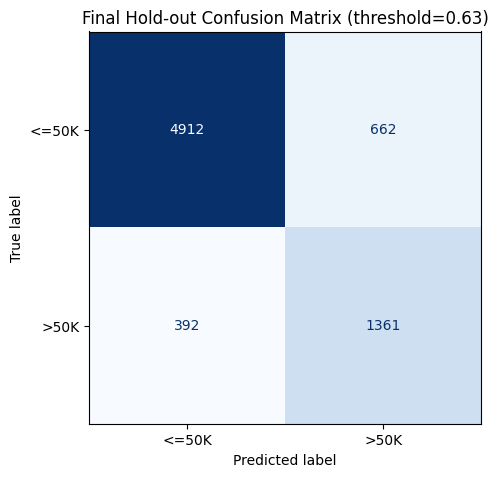

In [29]:
# ==========================================================
# FINAL HOLD-OUT EVALUATION AT THE FROZEN PRODUCTION THRESHOLD
# ==========================================================
# This is the ONE AND ONLY evaluation on X_test. No model, imbalance, or threshold decision
# is made from these numbers -- they are reported, not used to pick anything further.

test_proba_final = final_model_pipeline.predict_proba(X_test)[:, 1]

test_pred_final = (
    test_proba_final >= PRODUCTION_THRESHOLD
).astype(int)

final_holdout_metrics = {
    "Threshold": PRODUCTION_THRESHOLD,
    "Accuracy": accuracy_score(y_test, test_pred_final),
    "Precision": precision_score(
        y_test, test_pred_final, zero_division=0
    ),
    "Recall": recall_score(
        y_test, test_pred_final, zero_division=0
    ),
    "F1": f1_score(
        y_test, test_pred_final, zero_division=0
    ),
    "ROC AUC": roc_auc_score(
        y_test, test_proba_final
    ),
    "PR AUC": average_precision_score(
        y_test, test_proba_final
    ),
}

final_holdout_df = pd.DataFrame(
    [final_holdout_metrics]
)

print("FINAL HOLD-OUT PERFORMANCE (test set, frozen production threshold)")
display(final_holdout_df.round(4))

# --- Final confusion matrix ---
final_cm = confusion_matrix(y_test, test_pred_final)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(final_cm, display_labels=["<=50K", ">50K"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Final Hold-out Confusion Matrix (threshold={PRODUCTION_THRESHOLD:.2f})")
plt.tight_layout()
plt.show()


In [30]:
# ==========================================================
# Save the final pipeline bundle
# ==========================================================

capstone_bundle = {
    "pipeline": final_model_pipeline,
    "threshold": PRODUCTION_THRESHOLD,
    "imbalance_approach": CHOSEN_APPROACH,
    "raw_input_columns": X_train.columns.tolist(),
    "sklearn_version": sklearn.__version__,
    "random_state": RANDOM_STATE,
}

joblib.dump(capstone_bundle, "capstone_income_pipeline.joblib")
print("Saved -> capstone_income_pipeline.joblib")
print("Bundle keys:", list(capstone_bundle.keys()))


Saved -> capstone_income_pipeline.joblib
Bundle keys: ['pipeline', 'threshold', 'imbalance_approach', 'raw_input_columns', 'sklearn_version', 'random_state']


## `inference.py`

Written to disk as a standalone script (not notebook-only code), so it can be imported or run
independently of this notebook, e.g. from a batch job or a served endpoint.


In [31]:
%%writefile inference.py
"""
Standalone inference script for the Adult Income capstone model.

Usage:
    from inference import load_pipeline, predict

    bundle = load_pipeline("capstone_income_pipeline.joblib")
    result = predict(bundle, {"age": 42, "workclass": "Private", ...})
"""
import warnings
import joblib
import numpy as np
import pandas as pd


class InputValidationError(ValueError):
    """Raised when raw input rows don't match what the pipeline expects."""


def load_pipeline(path: str = "capstone_income_pipeline.joblib") -> dict:
    """Load the saved pipeline bundle (pipeline + threshold + metadata)."""
    return joblib.load(path)


def _to_dataframe(rows, expected_columns):
    """Accept a dict, a list of dicts, or a DataFrame; return a validated DataFrame."""
    if isinstance(rows, pd.DataFrame):
        df = rows.copy()
    elif isinstance(rows, dict):
        df = pd.DataFrame([rows])
    elif isinstance(rows, list):
        df = pd.DataFrame(rows)
    else:
        raise InputValidationError(
            f"Unsupported input type {type(rows)}; expected dict, list[dict], or DataFrame."
        )

    missing = set(expected_columns) - set(df.columns)
    if missing:
        raise InputValidationError(f"Missing required columns: {sorted(missing)}")

    # Extra columns are dropped rather than rejected -- unseen categories inside
    # existing columns are handled by the pipeline's OneHotEncoder(handle_unknown="ignore"),
    # but *extra columns the pipeline was never trained on* would break the
    # ColumnTransformer's column-name matching, so they're excluded explicitly here.
    return df[expected_columns]


def _global_importance_fallback(classifier_step, feature_names, n):
    """Global (not row-specific) fallback, clearly labeled as such in its output."""
    if hasattr(classifier_step, "feature_importances_"):
        importances = classifier_step.feature_importances_
        top_idx = np.argsort(importances)[::-1][:n]
        return [
            {
                "feature": feature_names[i] if i < len(feature_names) else f"feature_{i}",
                "importance": float(importances[i]),
                "note": "global importance fallback (not row-specific)",
            }
            for i in top_idx
        ]
    return [{"note": "no contribution explanation available (shap missing, no feature_importances_)"}]


def _top_contributing_features(pipeline, row_df, n=3):
    """
    Best-effort top-N contributing features for a single row.

    Tries SHAP TreeExplainer first (most accurate); falls back to a
    global-importance approximation only if shap is genuinely unavailable.
    A structural bug (e.g. an unexpected pipeline shape) is NOT silently
    swallowed as if it were a missing dependency -- it's logged via
    warnings.warn so it surfaces in monitoring instead.

    Note on pipeline structure: `feature_engineering` and `preprocessing`
    are separate top-level steps (not one nested step), because the
    pipeline may have been built with imblearn's Pipeline, which rejects a
    nested Pipeline-within-a-Pipeline step.
    """
    feature_engineering_step = pipeline.named_steps["feature_engineering"]
    preprocessing_step = pipeline.named_steps["preprocessing"]
    classifier_step = pipeline.named_steps["classifier"]

    ohe = preprocessing_step.named_transformers_["categorical"].named_steps["encoder"]
    numeric_cols = preprocessing_step.transformers_[0][2]
    categorical_cols = preprocessing_step.transformers_[1][2]
    feature_names = list(numeric_cols) + ohe.get_feature_names_out(categorical_cols).tolist()

    try:
        import shap
    except ImportError:
        return _global_importance_fallback(classifier_step, feature_names, n)

    try:
        row_fe = feature_engineering_step.transform(row_df)
        transformed = preprocessing_step.transform(row_fe)

        explainer = shap.TreeExplainer(classifier_step)
        shap_values = explainer.shap_values(transformed)
        values = shap_values[1] if isinstance(shap_values, list) else shap_values
        row_shap = pd.Series(np.ravel(values[0]), index=feature_names)
        top = row_shap.abs().sort_values(ascending=False).head(n)
        return [{"feature": f, "shap_value": float(row_shap[f])} for f in top.index]
    except Exception as e:
        warnings.warn(
            f"SHAP explanation failed ({type(e).__name__}: {e}); falling back to global "
            f"feature importances. This may indicate a real bug (e.g. a pipeline "
            f"structure mismatch), not just a missing dependency -- investigate if this "
            f"appears in production logs.",
            RuntimeWarning,
        )
        return _global_importance_fallback(classifier_step, feature_names, n)


def predict(bundle: dict, rows, top_n_features: int = 3):
    """
    Run inference on one or more raw input rows.

    Parameters
    ----------
    bundle : dict returned by load_pipeline()
    rows   : dict, list[dict], or DataFrame of RAW (unprocessed) input rows
    top_n_features : how many top contributing features to return per row

    Returns
    -------
    list[dict] -- one entry per input row:
        {"probability": float, "predicted_class": int, "top_features": [...]}
    """
    pipeline = bundle["pipeline"]
    threshold = bundle["threshold"]
    expected_columns = bundle["raw_input_columns"]

    df = _to_dataframe(rows, expected_columns)

    probabilities = pipeline.predict_proba(df)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    results = []
    for i in range(len(df)):
        row_df = df.iloc[[i]]
        results.append({
            "probability": float(probabilities[i]),
            "predicted_class": int(predictions[i]),
            "threshold_used": threshold,
            "top_features": _top_contributing_features(pipeline, row_df, n=top_n_features),
        })
    return results


Writing inference.py


### Unit tests for `inference.py`

Tests cover: a missing required column raises `InputValidationError`; an unseen category value
is handled gracefully (not rejected, since `OneHotEncoder(handle_unknown="ignore")` already
covers this at the pipeline level); and a valid input returns the expected output schema.


In [32]:
%%writefile test_inference.py
"""
Unit tests for inference.py.

Run with:  python -m pytest test_inference.py -v
(or python -m unittest test_inference -v)
"""
import unittest
import pandas as pd
from inference import load_pipeline, predict, _to_dataframe, InputValidationError


class TestInputValidation(unittest.TestCase):

    def setUp(self):
        self.bundle = load_pipeline("capstone_income_pipeline.joblib")
        self.expected_columns = self.bundle["raw_input_columns"]
        self.threshold = self.bundle["threshold"]
        # A minimal valid row built from the expected schema; values are
        # deliberately generic/plausible rather than copied from real data.
        self.valid_row = {col: "Private" if col in
                           ("workclass", "education", "marital-status", "occupation",
                            "relationship", "race", "sex", "native-country")
                           else 30 for col in self.expected_columns}

    def test_missing_column_raises(self):
        incomplete_row = dict(self.valid_row)
        removed_col = self.expected_columns[0]
        del incomplete_row[removed_col]
        with self.assertRaises(InputValidationError):
            _to_dataframe(incomplete_row, self.expected_columns)

    def test_unseen_category_does_not_raise(self):
        # OneHotEncoder(handle_unknown="ignore") should absorb a category the
        # encoder never saw during training, rather than the pipeline erroring out.
        weird_row = dict(self.valid_row)
        weird_row["workclass"] = "Totally-Unseen-Category-XYZ"
        try:
            result = predict(self.bundle, weird_row)
        except Exception as e:
            self.fail(f"predict() raised {type(e).__name__} on an unseen category: {e}")
        self.assertEqual(len(result), 1)

    def test_valid_input_output_schema(self):
        result = predict(self.bundle, self.valid_row)
        self.assertEqual(len(result), 1)
        row_result = result[0]
        self.assertIn("probability", row_result)
        self.assertIn("predicted_class", row_result)
        self.assertIn("threshold_used", row_result)
        self.assertIn("top_features", row_result)
        self.assertTrue(0.0 <= row_result["probability"] <= 1.0)
        self.assertIn(row_result["predicted_class"], (0, 1))

    def test_list_of_dicts_input(self):
        result = predict(self.bundle, [self.valid_row, self.valid_row])
        self.assertEqual(len(result), 2)

    def test_dataframe_input(self):
        df = pd.DataFrame([self.valid_row])
        result = predict(self.bundle, df)
        self.assertEqual(len(result), 1)

    def test_threshold_correctness(self):
        # predicted_class must be exactly the frozen bundle threshold applied to probability --
        # never an independently-defined threshold inside inference.py.
        result = predict(self.bundle, self.valid_row)
        row_result = result[0]
        self.assertEqual(row_result["threshold_used"], self.threshold)
        expected_class = int(row_result["probability"] >= self.threshold)
        self.assertEqual(row_result["predicted_class"], expected_class)

    def test_top3_contributions(self):
        result = predict(self.bundle, self.valid_row)
        top_features = result[0]["top_features"]
        self.assertTrue(len(top_features) > 0, "top_features must be non-empty for a valid input")
        self.assertLessEqual(len(top_features), 3, "at most 3 contributing features expected")


if __name__ == "__main__":
    unittest.main()


Writing test_inference.py


In [33]:
# ==========================================================
# Run the unit tests
# ==========================================================
!python -m pytest test_inference.py -v


============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: anyio-4.14.2
collected 7 items                                                              

test_inference.py::TestInputValidation::test_dataframe_input PASSED      [ 14%]
test_inference.py::TestInputValidation::test_list_of_dicts_input PASSED  [ 28%]
test_inference.py::TestInputValidation::test_missing_column_raises PASSED [ 42%]
test_inference.py::TestInputValidation::test_threshold_correctness PASSED [ 57%]
test_inference.py::TestInputValidation::test_top3_contributions PASSED   [ 71%]
test_inference.py::TestInputValidation::test_unseen_category_does_not_raise PASSED [ 85%]
test_inference.py::TestInputValidation::test_valid_input_output_schema PASSED [100%]

============================== 7 passed in 2.28s ===============================


## Final Consistency Audit

Verify that the model, imbalance strategy, threshold, saved bundle, and inference script all agree before generating the executive report and presentation outline.

In [34]:
# ==========================================================
# Final consistency audit
# ==========================================================
import importlib
import inference as _inference_module
importlib.reload(_inference_module)

_bundle_reloaded = _inference_module.load_pipeline("capstone_income_pipeline.joblib")

_checks = {
    "notebook PRODUCTION_THRESHOLD == saved bundle threshold":
        PRODUCTION_THRESHOLD == _bundle_reloaded["threshold"],
    "notebook CHOSEN_APPROACH == saved bundle imbalance_approach":
        CHOSEN_APPROACH == _bundle_reloaded["imbalance_approach"],
    "final_holdout_metrics['Threshold'] == PRODUCTION_THRESHOLD":
        final_holdout_metrics["Threshold"] == PRODUCTION_THRESHOLD,
    "local case production_threshold values == PRODUCTION_THRESHOLD":
        all(c["production_threshold"] == PRODUCTION_THRESHOLD for c in local_case_details),
    "saved bundle raw_input_columns == X_train.columns":
        list(_bundle_reloaded["raw_input_columns"]) == list(X_train.columns),
}

# End-to-end: run inference.py's predict() with the reloaded bundle and confirm the
# threshold it applies is the SAME frozen threshold (single source of truth, no
# independently-defined threshold inside inference.py).
_sample_row = X_test.iloc[0].to_dict()
_inference_result = _inference_module.predict(_bundle_reloaded, _sample_row)[0]
_checks["inference.py predict() threshold_used == PRODUCTION_THRESHOLD"] = (
    _inference_result["threshold_used"] == PRODUCTION_THRESHOLD
)

all_pass = True
for name, ok in _checks.items():
    status = "PASS" if ok else "FAIL"
    if not ok:
        all_pass = False
    print(f"[{status}] {name}")

assert all_pass, "Consistency audit failed -- see FAIL lines above."
print("\nAll consistency checks passed. There is exactly one production decision rule.")


[PASS] notebook PRODUCTION_THRESHOLD == saved bundle threshold
[PASS] notebook CHOSEN_APPROACH == saved bundle imbalance_approach
[PASS] final_holdout_metrics['Threshold'] == PRODUCTION_THRESHOLD
[PASS] local case production_threshold values == PRODUCTION_THRESHOLD
[PASS] saved bundle raw_input_columns == X_train.columns
[PASS] inference.py predict() threshold_used == PRODUCTION_THRESHOLD

All consistency checks passed. There is exactly one production decision rule.


## Executive Report (PDF)

Generated entirely from variables already computed above, so it always reflects the final model, threshold, and metrics -- nothing in `executive_report.pdf` is hand-typed.

In [35]:
# ==========================================================
# Generate executive_report.pdf from notebook variables (no hard-coded numbers)
# ==========================================================
!pip install reportlab

from reportlab.lib.pagesizes import letter
from reportlab.lib.units import inch
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib import colors

styles = getSampleStyleSheet()
h1, h2, body = styles["Heading1"], styles["Heading2"], styles["BodyText"]
small = ParagraphStyle("small", parent=body, fontSize=8, leading=10)

def _fmt_table(df, ncols_round=4):
    df2 = df.copy()
    for c in df2.select_dtypes(include=["float64", "float32"]).columns:
        df2[c] = df2[c].round(ncols_round)
    return [list(df2.columns)] + df2.astype(str).values.tolist()

def _styled_table(data):
    t = Table(data, hAlign="LEFT")
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#333333")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("FONTSIZE", (0, 0), (-1, -1), 7),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#f2f2f2")]),
    ]))
    return t

final_model_name = type(final_model_pipeline.named_steps["classifier"]).__name__

story = []
story.append(Paragraph("Executive Report -- Adult Income Classifier", h1))
story.append(Paragraph(
    "Business goal: predict whether an individual's annual income exceeds $50K, to support "
    "targeting/prioritization decisions that depend on likely income level.", body))
story.append(Spacer(1, 6))

story.append(Paragraph("Data & class imbalance", h2))
story.append(Paragraph(
    f"UCI/OpenML Adult dataset ({X.shape[0]} rows, {X.shape[1]} raw features). "
    f"Positive class (income &gt;$50K) is {y.mean():.1%} of the data "
    f"({(len(y)-y.sum())/y.sum():.2f}:1 negative:positive).", body))
story.append(Spacer(1, 6))

story.append(Paragraph("Final model & imbalance strategy", h2))
story.append(Paragraph(
    f"Final model: <b>{final_model_name}</b>. Final imbalance-handling strategy: "
    f"<b>{CHOSEN_APPROACH}</b>, selected by mean cross-validation F1 on X_train "
    f"(not by test-set performance). Final production threshold: "
    f"<b>{PRODUCTION_THRESHOLD:.2f}</b>, selected on a dedicated threshold-validation split "
    f"before the model was refit on all of X_train.", body))
story.append(Spacer(1, 8))

story.append(Paragraph("Key hold-out metrics (test set, frozen threshold)", h2))
story.append(_styled_table(_fmt_table(final_holdout_df)))
story.append(Spacer(1, 8))

story.append(Paragraph("Ensemble comparison (Task 1, test set, 0.5 cutoff)", h2))
story.append(_styled_table(_fmt_table(
    ensemble_comparison_df[["Model", "F1", "ROC AUC", "PR AUC", "Inference (ms/row)"]]
)))
story.append(Spacer(1, 8))

story.append(Paragraph("Interpretability -- top features", h2))
story.append(Paragraph(
    "Top contributing features by mean |SHAP value| (transformed/one-hot feature space): "
    + ", ".join(mean_abs_shap.head(8)["Feature"].tolist()) + ".", body))
story.append(Spacer(1, 6))

story.append(Paragraph("Local explanation summary", h2))
for case in local_case_details:
    feats = ", ".join(f"{f} ({d})" for f, v, d in case["top3"])
    story.append(Paragraph(
        f"<b>{case['case_type']}</b> (row {case['row']}): probability "
        f"{case['predicted_probability']:.4f} vs threshold {case['production_threshold']:.2f}. "
        f"Top contributing features: {feats}.", small))
story.append(Spacer(1, 8))

story.append(Paragraph("Fairness observations (numerical gaps)", h2))
story.append(Paragraph(
    f"By sex: F1 gap {sex_gaps['max_F1_minus_min_F1']:.4f}, recall gap "
    f"{sex_gaps['max_recall_minus_min_recall']:.4f}, predicted-positive-rate gap "
    f"{sex_gaps['max_pred_pos_rate_minus_min_pred_pos_rate']:.4f} "
    f"(worst group: {sex_gaps['worst_F1_group']}).<br/>"
    f"By race: F1 gap {race_gaps['max_F1_minus_min_F1']:.4f}, recall gap "
    f"{race_gaps['max_recall_minus_min_recall']:.4f}, predicted-positive-rate gap "
    f"{race_gaps['max_pred_pos_rate_minus_min_pred_pos_rate']:.4f} "
    f"(worst group: {race_gaps['worst_F1_group']}). These are associational gaps, not causal "
    f"claims; see the notebook's Disparities & Mitigations section for proposed mitigations.",
    small))
story.append(Spacer(1, 8))

story.append(Paragraph("Deployment artifact", h2))
story.append(Paragraph(
    "capstone_income_pipeline.joblib (pipeline + frozen threshold + imbalance_approach + "
    "raw_input_columns + sklearn_version + random_state), served via inference.py "
    "(dict / list[dict] / DataFrame in, probability + predicted class + threshold + top-3 "
    "contributing features out).", body))
story.append(Spacer(1, 6))

story.append(Paragraph("Recommended next steps", h2))
story.append(Paragraph(
    "1) Run an A/B test or controlled pilot: route a held-out slice of live traffic through "
    "the new model alongside the current process, compare business-relevant outcomes (not "
    "just F1) before full rollout. 2) Re-check the winning imbalance strategy on the "
    "stacking/XGBoost architectures from Task 1 to confirm the choice generalizes. "
    "3) Stand up the monitoring checklist (data drift, score drift, predicted-positive rate, "
    "rolling F1/recall, fairness gaps) before go-live, with the alert thresholds documented "
    "in the notebook. 4) Schedule quarterly retraining, re-running the full "
    "model/imbalance/fairness pipeline, with an event-triggered retrain path for confirmed "
    "drift.", body))

doc = SimpleDocTemplate(
    "executive_report.pdf", pagesize=letter,
    topMargin=0.55*inch, bottomMargin=0.55*inch, leftMargin=0.7*inch, rightMargin=0.7*inch,
)
doc.build(story)
print("Saved -> executive_report.pdf")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.0 MB/s eta 0:00:00
Saved -> executive_report.pdf


## Monitoring Checklist (One Page)

**What to monitor**

| Category | Signal | How |
|---|---|---|
| **Data drift** | Distribution shift in key input features (`age`, `hours-per-week`, `education`, `capital-gain`, `occupation`) | Population Stability Index (PSI) or KS-test between the training distribution and each week's incoming batch; flag any feature with PSI > 0.2 |
| **Label distribution** | Shift in the true positive rate (income > $50K) once ground truth becomes available (e.g. from a downstream system or delayed labeling) | Weekly rolling positive-rate vs. the training-time base rate (~23.9%) |
| **Model score distribution** | Shift in the distribution of predicted probabilities, even before labels arrive | Compare weekly score histogram (mean, std, percentiles) against the validation-set score distribution captured at training time |
| **Performance metrics** | F1, precision, recall, ROC AUC on any batch where labels do eventually arrive | Rolling window (e.g. trailing 30 days of labeled outcomes) compared against the recorded test-set baseline |
| **Fairness metrics** | Per-group (sex, race) recall/F1 gap, recomputed on new labeled data | Same grouped-metric computation as Task 3, run on a monthly cadence |
| **Prediction volume / latency** | Requests per day, per-row inference latency | Standard ops monitoring (this is not model-specific, but a sudden volume or latency change often co-occurs with a broken upstream feature feed) |

**Alert thresholds** (starting points — tune after observing real production variance)

- PSI > 0.2 on any of the 5 key input features → **warning**; PSI > 0.3 → **investigate before next retrain**
- Predicted positive rate drifts more than ±5 percentage points from the hold-out predicted-positive rate recorded at the frozen `PRODUCTION_THRESHOLD` (Task 3/4's final hold-out evaluation) → **warning**. This is compared against that hold-out baseline, *not* against the raw training-set label prevalence -- prevalence and the model's predicted-positive rate are not expected to be equal at a threshold other than the one that would exactly match them, so comparing predicted rate to raw prevalence would misfire on a perfectly healthy model.
- Rolling F1 drops more than 5 points below the recorded test-set F1 → **warning**; more than 10 points → **page on-call / consider rollback**
- Per-group F1 gap (sex or race) widens by more than 5 points relative to the Task-3 baseline gap → **flag for fairness review**, independent of overall F1

**Retraining cadence**

- **Scheduled:** quarterly retrain on the latest available labeled data, re-running Tasks 1-3 in full (model comparison, imbalance check, interpretability + fairness re-check) rather than only refitting weights — feature relationships can shift, not just the label rate.
- **Triggered:** any "investigate" or "page" alert above should trigger an out-of-cycle review, and a retrain if the root cause is confirmed to be genuine drift rather than a pipeline bug.
- Every retrain re-runs the Task-3 fairness check before deployment — a retrain that improves overall F1 but widens a group gap should not ship without an explicit decision to accept that trade-off.
